In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 5.5
fig_height = 3.5
fig_format = 'pdf'
fig_dpi = 300
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcSmVyc29uXERvY3VtZW50c1xxdWFydG8='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"c:\\Users\\Jerson\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\importlib\\_bootstrap.py": 1749683368.0, "c:\\Users\\Jerson\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\importlib\\_bootstrap_external.py": 1749683368.0, "c:\\Users\\Jerson\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\zipimport.py": 1749683368.0, "c:\\Users\\Jerson\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\codecs.py": 1749683368.0, "c:\\Users\\Jerson\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\encodings\\aliases.py": 1749683368.0, "c:\\Users\\Jerson\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\encodings\\__init__.py": 1749683368.0, "c:\\Users\\Jerson\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\encodings\\utf_8.py": 1749683368.0, "c:\\Users\\Jerson\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\encodings\\cp1252.py": 1749683368.0, "c:\\Users\\Jerson\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\abc.py": 1749683368.0, "c:\\Users\\Jerson\\AppData\\Local\\Programs\\Pyth

In [2]:
#| label: setup-data
#| echo: false

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Configuración de reproducibilidad
np.random.seed(42)

# Cargar datos
df = pd.read_csv('data/datos.csv')

# Información general del dataset
display(Markdown(f"""
#### Información General del Dataset:
- **Observaciones:** {len(df):,}
- **Variables:** {df.shape[1]}
- **Periodo:** Abril 1912 (Hundimiento del Titanic)
- **Fuente:** Registros históricos de pasajeros
"""))


#### Información General del Dataset:
- **Observaciones:** 891
- **Variables:** 12
- **Periodo:** Abril 1912 (Hundimiento del Titanic)
- **Fuente:** Registros históricos de pasajeros


In [3]:
#| label: data-overview
#| echo: false

# Mostrar primeras filas y estructura
display(df.head().style.set_caption("Primeras 5 filas del dataset").hide(axis='index'))

display(pd.DataFrame(df.info()).style.set_caption("Información del dataset").hide(axis='index'))

display(df.describe().style.set_caption("Estadísticas descriptivas").hide(axis='index'))

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.250000,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000000,1,0,PC 17599,71.283300,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.925000,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.100000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.050000,nan,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
#| label: missing-values

# Análisis de valores faltantes
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_data.index,
    'Valores_Faltantes': missing_data.values,
    'Porcentaje': missing_percent.values
}).sort_values('Porcentaje', ascending=False)

display(missing_df[missing_df['Valores_Faltantes'] > 0].style.format({
    'Porcentaje': '{:.2f}%'
}).set_caption("Análisis de Valores Faltantes").hide(axis='index'))

Variable,Valores_Faltantes,Porcentaje
Cabin,687,77.10%
Age,177,19.87%
Embarked,2,0.22%


In [5]:
#| label: variable-types

# Clasificación de variables
variables_categoricas = ['Survived', 'Pclass', 'Sex', 'Embarked']
variables_numericas = ['Age', 'SibSp', 'Parch', 'Fare']
variables_texto = ['Name', 'Ticket', 'Cabin']

display(Markdown(f"""
#### Clasificación de Variables:

- **Variables Categóricas:** {len(variables_categoricas)}
- {', '.join(variables_categoricas)}

- **Variables Numéricas:** {len(variables_numericas)}
- {', '.join(variables_numericas)}

- **Variables de Texto:** {len(variables_texto)}
- {', '.join(variables_texto)}
"""))


#### Clasificación de Variables:

- **Variables Categóricas:** 4
- Survived, Pclass, Sex, Embarked

- **Variables Numéricas:** 4
- Age, SibSp, Parch, Fare

- **Variables de Texto:** 3
- Name, Ticket, Cabin


In [6]:
#| label: survival-analysis

# Análisis de supervivencia por variables clave
survival_stats = {}

# Por clase
survival_class = df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean']).round(4)
survival_class.columns = ['Total_Pasajeros', 'Supervivientes', 'Tasa_Supervivencia']

# Por sexo
survival_sex = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean']).round(4)
survival_sex.columns = ['Total_Pasajeros', 'Supervivientes', 'Tasa_Supervivencia']

# Por puerto de embarque
survival_embarked = df.groupby('Embarked')['Survived'].agg(['count', 'sum', 'mean']).round(4)
survival_embarked.columns = ['Total_Pasajeros', 'Supervivientes', 'Tasa_Supervivencia']

display(survival_class.style.format({
    'Tasa_Supervivencia': '{:.2%}'
}).set_caption("Tasa de Supervivencia por Clase"))


display(survival_sex.style.format({
    'Tasa_Supervivencia': '{:.2%}'
}).set_caption("Tasa de Supervivencia por Sexo"))

display(survival_embarked.style.format({
    'Tasa_Supervivencia': '{:.2%}'
}).set_caption("Tasa de Supervivencia por Puerto de Embarque"))

,Total_Pasajeros,Supervivientes,Tasa_Supervivencia
Pclass,,,
1,216,136,62.96%
2,184,87,47.28%
3,491,119,24.24%


,Total_Pasajeros,Supervivientes,Tasa_Supervivencia
Sex,,,
female,314,233,74.20%
male,577,109,18.89%


,Total_Pasajeros,Supervivientes,Tasa_Supervivencia
Embarked,,,
C,168,93,55.36%
Q,77,30,38.96%
S,644,217,33.70%


In [7]:
#| label: multifactor-analysis

# Análisis combinado de clase y sexo
survival_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].agg(['count', 'mean']).round(4)
survival_class_sex.columns = ['Total_Pasajeros', 'Tasa_Supervivencia']

display(survival_class_sex.style.format({
    'Tasa_Supervivencia': '{:.2%}'
}).set_caption("Análisis Multifactorial - Clase y Sexo"))

# Crear variable de categoría combinada para análisis
df['Categoria'] = df['Pclass'].astype(str) + '_' + df['Sex']

In [8]:
#| label: age-group-analysis

# Crear grupos de edad
df['Grupo_Edad'] = pd.cut(df['Age'], 
                         bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Niño', 'Adolescente', 'Adulto_Joven', 'Adulto', 'Mayor'],
                         include_lowest=True)

# Análisis de supervivencia por grupo de edad
survival_age = df.groupby('Grupo_Edad')['Survived'].agg(['count', 'sum', 'mean']).round(4)
survival_age.columns = ['Total_Pasajeros', 'Supervivientes', 'Tasa_Supervivencia']

display(survival_age.style.format({
    'Tasa_Supervivencia': '{:.2%}'
}).set_caption("Tasa de Supervivencia por Grupo de Edad"))

,Total_Pasajeros,Supervivientes,Tasa_Supervivencia
Grupo_Edad,,,
Niño,69,40,57.97%
Adolescente,70,30,42.86%
Adulto_Joven,358,137,38.27%
Adulto,195,78,40.00%
Mayor,22,5,22.73%


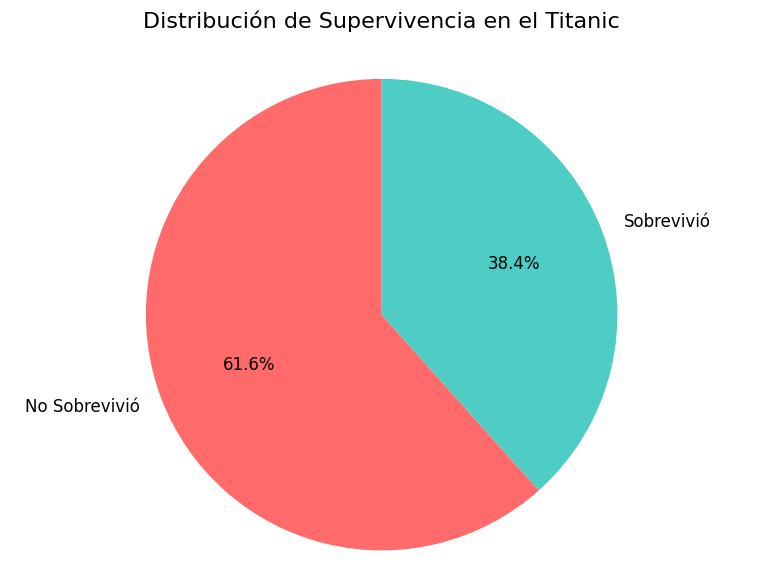

In [9]:
#| label: fig-survival-overview
#| fig-cap: Distribución general de supervivientes vs. no supervivientes

plt.figure(figsize=(8, 6))
survival_counts = df['Survived'].value_counts()
labels = ['No Sobrevivió', 'Sobrevivió']
colors = ['#ff6b6b', '#4ecdc4']

plt.pie(survival_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Supervivencia en el Titanic', fontsize=16, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

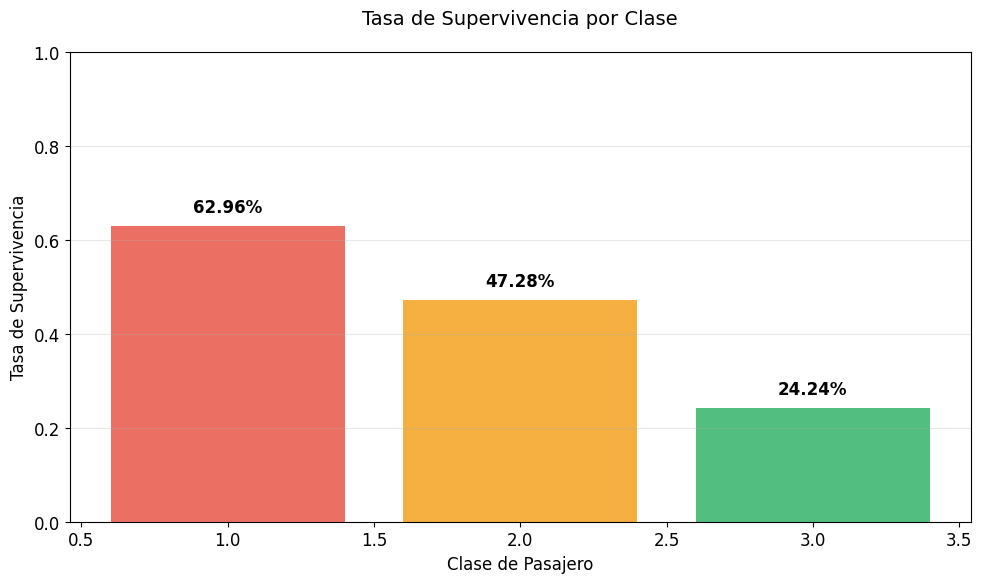

In [10]:
#| label: fig-survival-class
#| fig-cap: Tasa de supervivencia por clase de pasajero con codificación de color intuitiva

plt.figure(figsize=(10, 6))
class_survival = df.groupby('Pclass')['Survived'].mean()
colors = ['#e74c3c', '#f39c12', '#27ae60']  # Rojo, Naranja, Verde (peor a mejor)

bars = plt.bar(class_survival.index, class_survival.values, color=colors, alpha=0.8)
plt.xlabel('Clase de Pasajero', fontsize=12)
plt.ylabel('Tasa de Supervivencia', fontsize=12)
plt.title('Tasa de Supervivencia por Clase', fontsize=14, pad=20)
plt.ylim(0, 1)

# Agregar valores en las barras
for bar, value in zip(bars, class_survival.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{value:.2%}', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

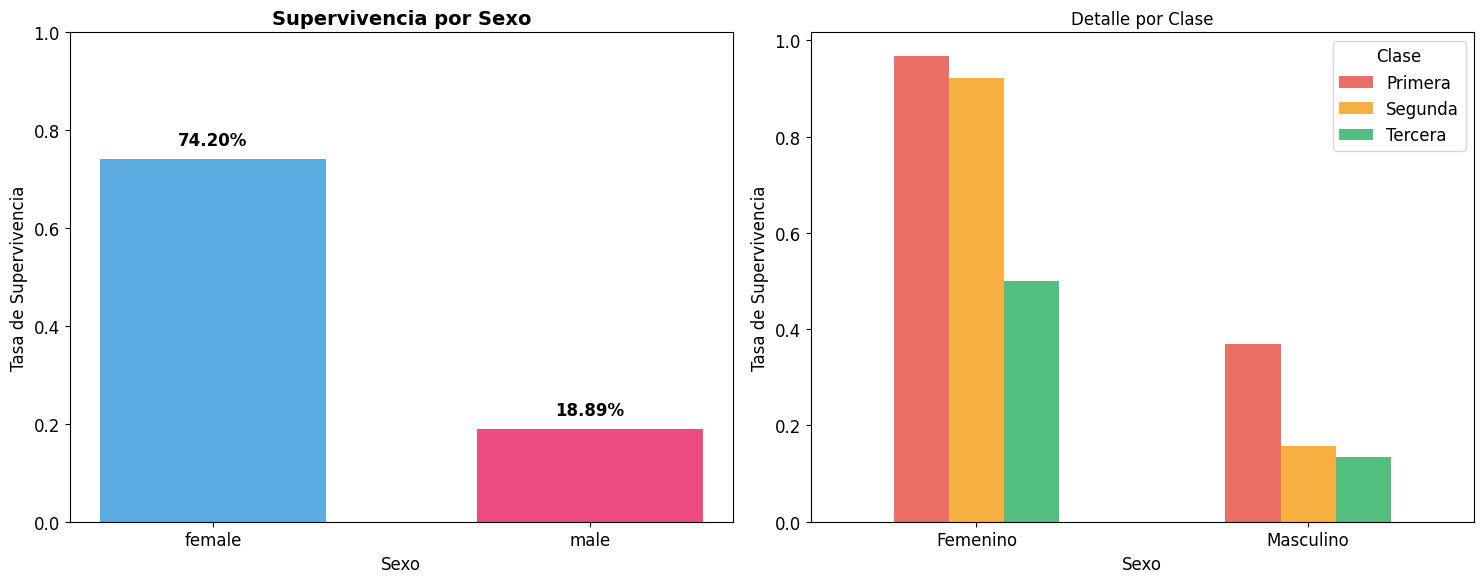

In [11]:
#| label: fig-survival-sex-class
#| fig-cap: Supervivencia por sexo y clase con jerarquía visual clara

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico principal - Supervivencia por sexo
sex_survival = df.groupby('Sex')['Survived'].mean()
bars1 = ax1.bar(sex_survival.index, sex_survival.values, 
                color=['#3498db', '#e91e63'], alpha=0.8, width=0.6)
ax1.set_xlabel('Sexo', fontsize=12)
ax1.set_ylabel('Tasa de Supervivencia', fontsize=12)
ax1.set_title('Supervivencia por Sexo', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1)

for bar, value in zip(bars1, sex_survival.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{value:.2%}', ha='center', va='bottom', fontweight='bold')

# Gráfico secundario - Detalle por clase y sexo
survival_detail = df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
survival_detail.plot(kind='bar', ax=ax2, color=['#e74c3c', '#f39c12', '#27ae60'], alpha=0.8)
ax2.set_xlabel('Sexo', fontsize=12)
ax2.set_ylabel('Tasa de Supervivencia', fontsize=12)
ax2.set_title('Detalle por Clase', fontsize=12)
ax2.legend(title='Clase', labels=['Primera', 'Segunda', 'Tercera'])
ax2.set_xticklabels(['Femenino', 'Masculino'], rotation=0)

plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

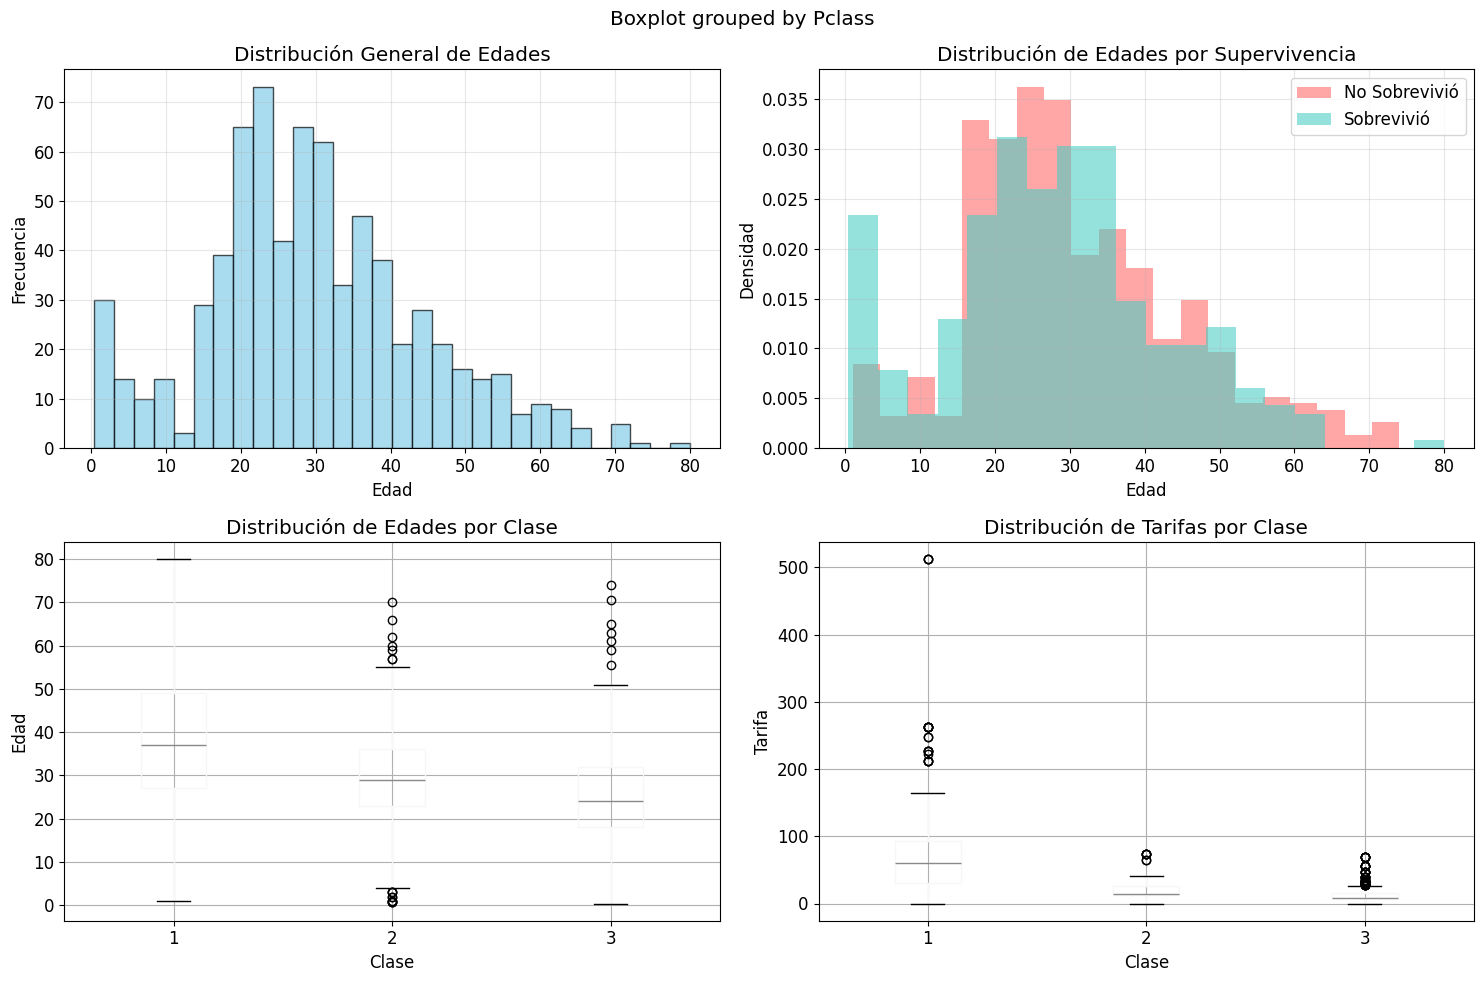

In [12]:
#| label: fig-age-distribution
#| fig-cap: Distribución de edades con escala apropiada y proporciones claras

plt.figure(figsize=(12, 8))

# Crear subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Histograma de edades general
ax1.hist(df['Age'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_xlabel('Edad')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución General de Edades')
ax1.grid(True, alpha=0.3)

# Histograma por supervivencia
for survived, color, label in [(0, '#ff6b6b', 'No Sobrevivió'), (1, '#4ecdc4', 'Sobrevivió')]:
    subset = df[df['Survived'] == survived]['Age'].dropna()
    ax2.hist(subset, bins=20, alpha=0.6, color=color, label=label, density=True)
ax2.set_xlabel('Edad')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de Edades por Supervivencia')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Boxplot de edades por clase
df.boxplot(column='Age', by='Pclass', ax=ax3)
ax3.set_xlabel('Clase')
ax3.set_ylabel('Edad')
ax3.set_title('Distribución de Edades por Clase')

# Boxplot de tarifa por clase
df.boxplot(column='Fare', by='Pclass', ax=ax4)
ax4.set_xlabel('Clase')
ax4.set_ylabel('Tarifa')
ax4.set_title('Distribución de Tarifas por Clase')

plt.tight_layout()
plt.show()

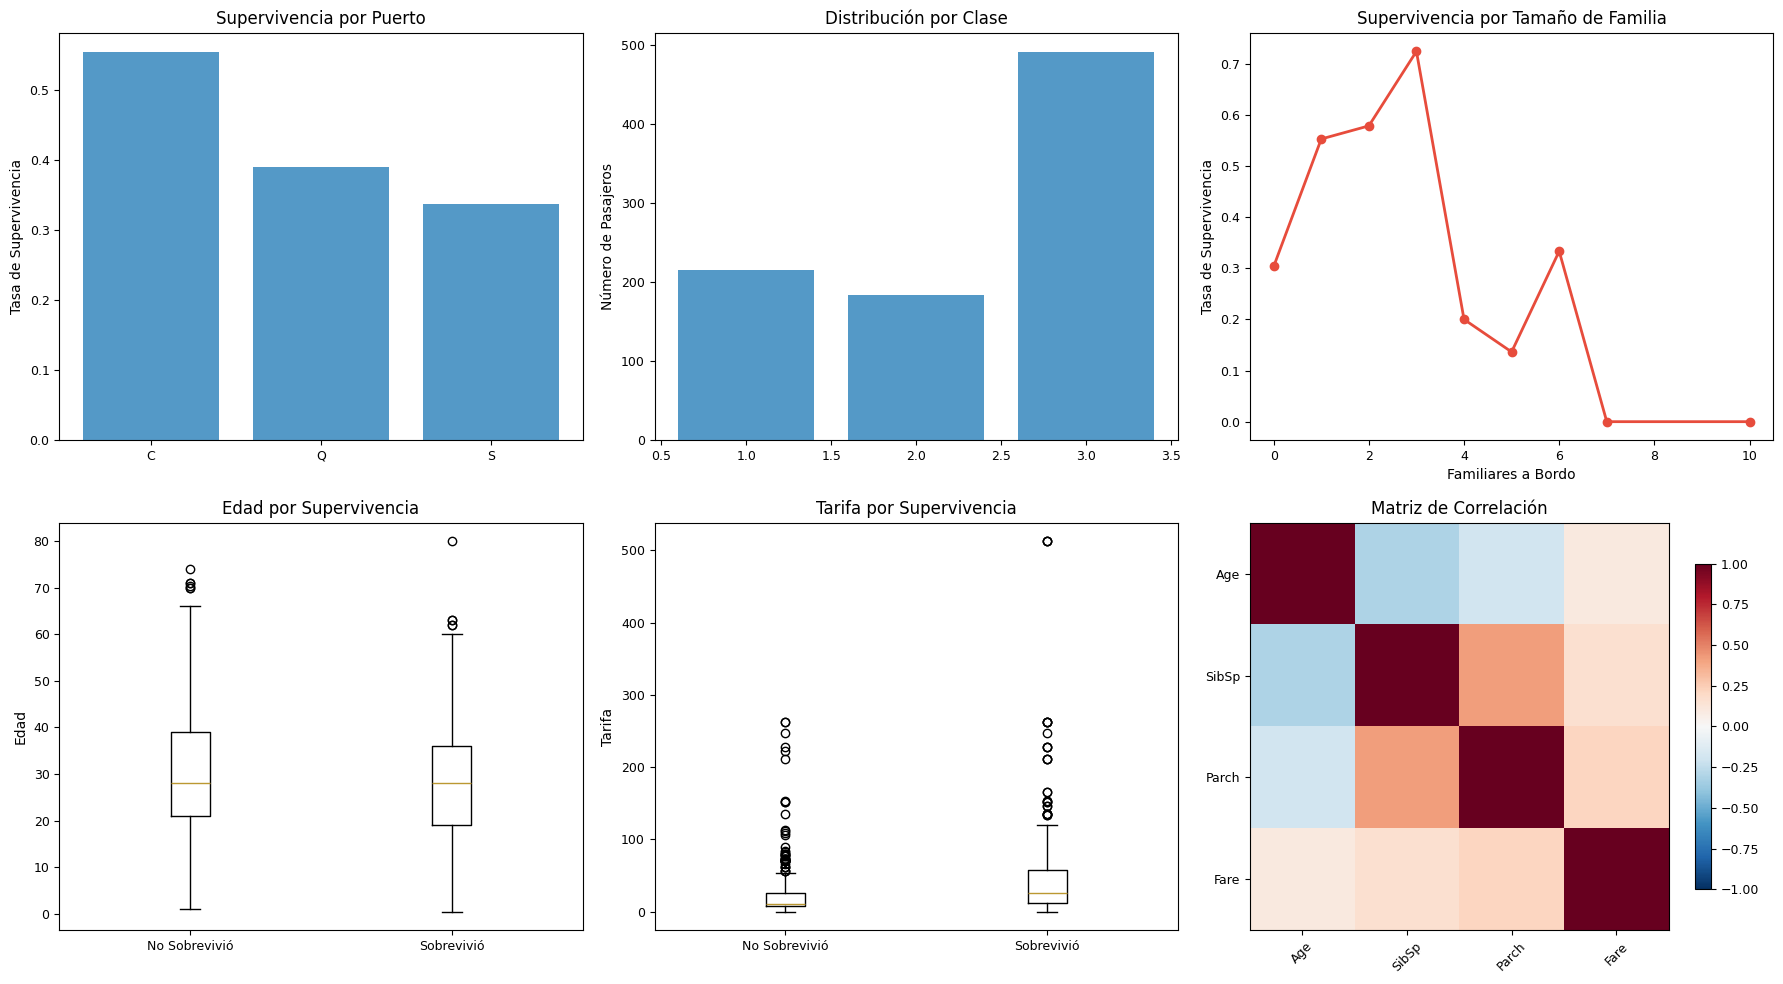

In [13]:
#| label: fig-consistent-style
#| fig-cap: Serie de gráficos con estilo consistente para comparación

# Configurar estilo consistente
style_config = {
    'figure.figsize': (12, 8),
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
}

with plt.rc_context(style_config):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Colores consistentes
    primary_color = '#2980b9'
    secondary_color = '#e74c3c'
    
    # 1. Supervivencia por puerto de embarque
    embarked_survival = df.groupby('Embarked')['Survived'].mean()
    axes[0,0].bar(embarked_survival.index, embarked_survival.values, color=primary_color, alpha=0.8)
    axes[0,0].set_title('Supervivencia por Puerto')
    axes[0,0].set_ylabel('Tasa de Supervivencia')
    
    # 2. Distribución por clase
    class_counts = df['Pclass'].value_counts().sort_index()
    axes[0,1].bar(class_counts.index, class_counts.values, color=primary_color, alpha=0.8)
    axes[0,1].set_title('Distribución por Clase')
    axes[0,1].set_ylabel('Número de Pasajeros')
    
    # 3. Familiares a bordo
    df['Family_Size'] = df['SibSp'] + df['Parch']
    family_survival = df.groupby('Family_Size')['Survived'].mean()
    axes[0,2].plot(family_survival.index, family_survival.values, 
                   marker='o', color=secondary_color, linewidth=2, markersize=6)
    axes[0,2].set_title('Supervivencia por Tamaño de Familia')
    axes[0,2].set_ylabel('Tasa de Supervivencia')
    axes[0,2].set_xlabel('Familiares a Bordo')
    
    # 4. Edad por supervivencia
    axes[1,0].boxplot([df[df['Survived']==0]['Age'].dropna(), 
                       df[df['Survived']==1]['Age'].dropna()],
                      labels=['No Sobrevivió', 'Sobrevivió'])
    axes[1,0].set_title('Edad por Supervivencia')
    axes[1,0].set_ylabel('Edad')
    
    # 5. Tarifa por supervivencia  
    axes[1,1].boxplot([df[df['Survived']==0]['Fare'].dropna(), 
                       df[df['Survived']==1]['Fare'].dropna()],
                      labels=['No Sobrevivió', 'Sobrevivió'])
    axes[1,1].set_title('Tarifa por Supervivencia')
    axes[1,1].set_ylabel('Tarifa')
    
    # 6. Correlación entre variables numéricas
    corr_matrix = df[variables_numericas].corr()
    im = axes[1,2].imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    axes[1,2].set_xticks(range(len(variables_numericas)))
    axes[1,2].set_yticks(range(len(variables_numericas)))
    axes[1,2].set_xticklabels(variables_numericas, rotation=45)
    axes[1,2].set_yticklabels(variables_numericas)
    axes[1,2].set_title('Matriz de Correlación')
    
    # Agregar colorbar
    plt.colorbar(im, ax=axes[1,2], shrink=0.8)
    
    plt.tight_layout()
    plt.show()

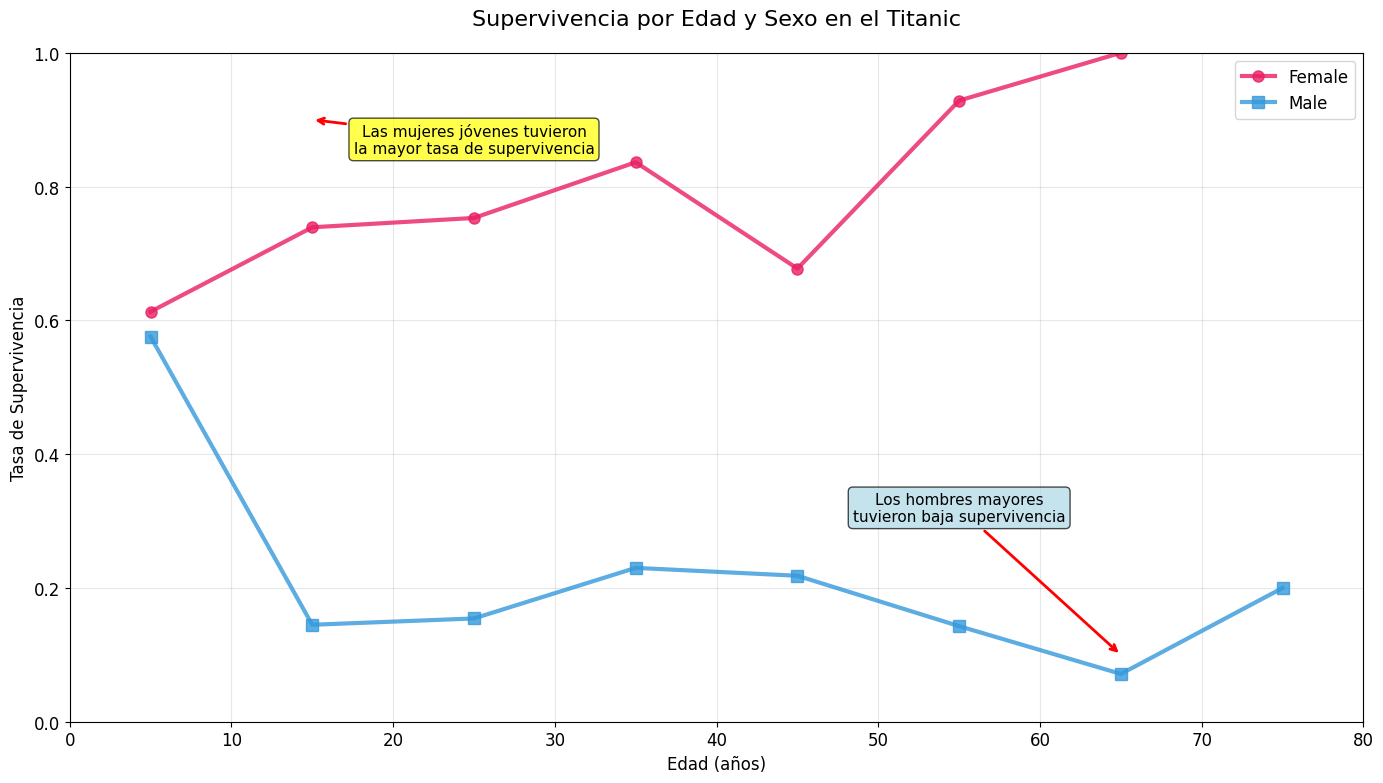

In [14]:
#| label: fig-annotated-insights
#| fig-cap: Gráfico con anotaciones contextuales destacando insights clave

plt.figure(figsize=(14, 8))

# Crear gráfico de supervivencia por edad y sexo
for sex, color, marker in [('female', '#e91e63', 'o'), ('male', '#3498db', 's')]:
    subset = df[df['Sex'] == sex]
    age_bins = pd.cut(subset['Age'], bins=range(0, 81, 10))
    survival_by_age = subset.groupby(age_bins)['Survived'].mean()
    
    plt.plot(range(5, 76, 10), survival_by_age.values, 
             color=color, marker=marker, linewidth=3, markersize=8, 
             label=f'{sex.capitalize()}', alpha=0.8)

plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Tasa de Supervivencia', fontsize=12)
plt.title('Supervivencia por Edad y Sexo en el Titanic', fontsize=16, pad=20)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Anotaciones contextuales
plt.annotate('Las mujeres jóvenes tuvieron\nla mayor tasa de supervivencia', 
             xy=(15, 0.9), xytext=(25, 0.85),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, ha='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.annotate('Los hombres mayores\ntuvieron baja supervivencia', 
             xy=(65, 0.1), xytext=(55, 0.3),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, ha='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

plt.ylim(0, 1)
plt.xlim(0, 80)
plt.tight_layout()
plt.show()

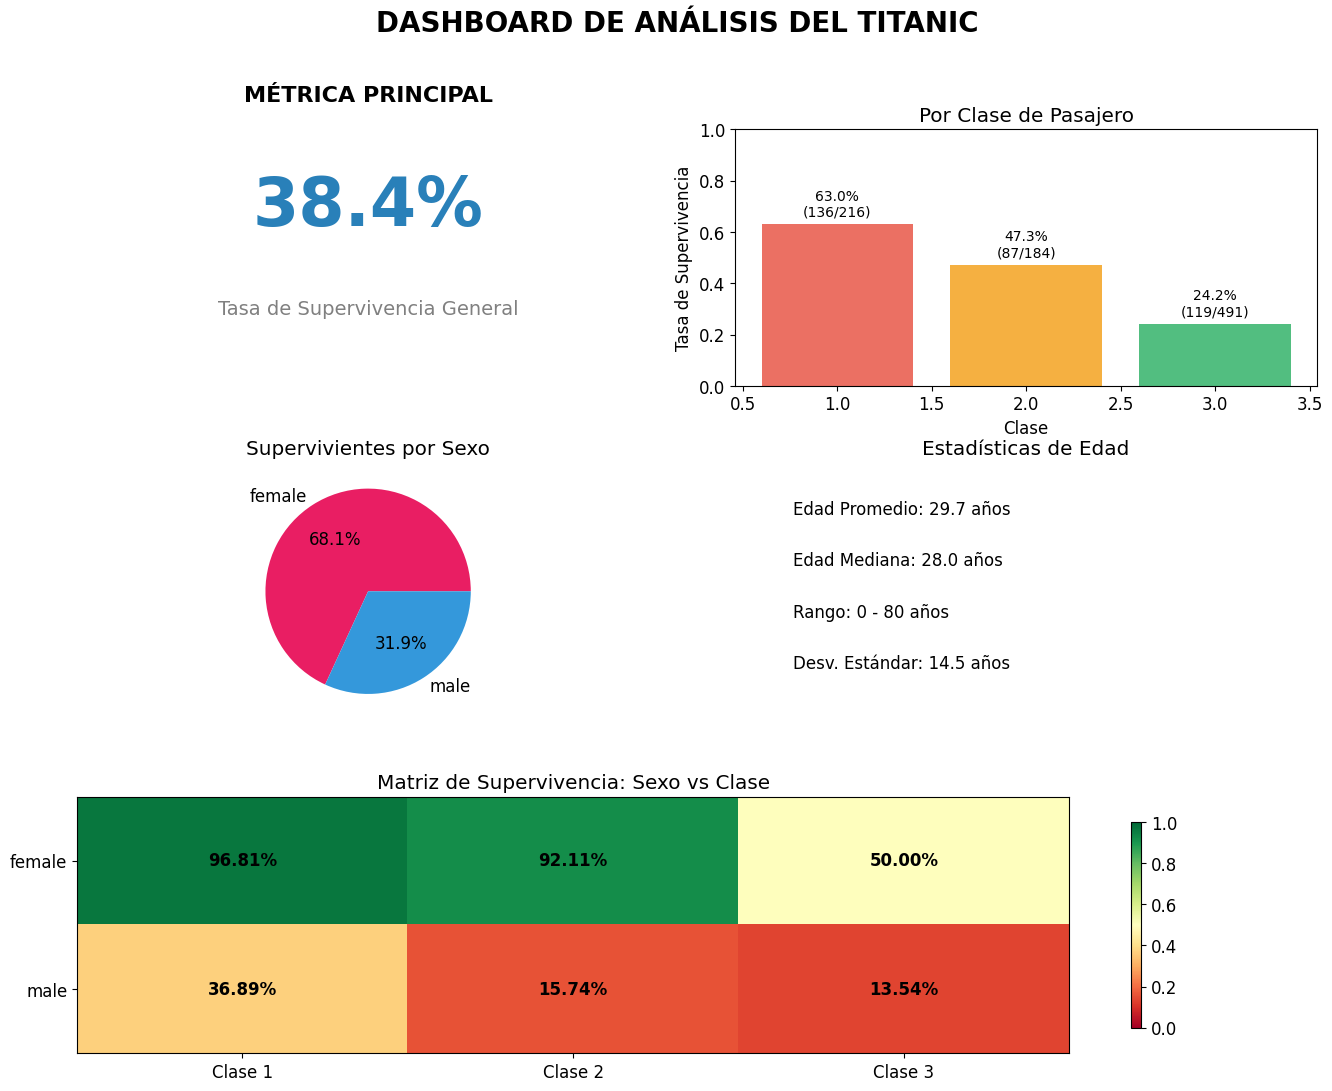

In [15]:
#| label: fig-dashboard-style
#| fig-cap: Dashboard estilo con múltiples métricas clave

# Crear un dashboard con métricas clave
fig = plt.figure(figsize=(16, 12))

# Layout del dashboard
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Métricas principales
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2:])
ax3 = fig.add_subplot(gs[1, :2])
ax4 = fig.add_subplot(gs[1, 2:])
ax5 = fig.add_subplot(gs[2, :])

# 1. Supervivencia general
survival_rate = df['Survived'].mean()
total_passengers = len(df)
survivors = df['Survived'].sum()

ax1.text(0.5, 0.7, f'{survival_rate:.1%}', ha='center', va='center', 
         fontsize=48, fontweight='bold', color='#2980b9')
ax1.text(0.5, 0.3, 'Tasa de Supervivencia General', ha='center', va='center', 
         fontsize=14, color='gray')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')
ax1.set_title('MÉTRICA PRINCIPAL', fontsize=16, fontweight='bold', pad=20)

# 2. Distribución por clase con números
class_data = df.groupby('Pclass').agg({
    'Survived': ['count', 'sum', 'mean']
}).round(3)

# Aplanar las columnas multi-nivel correctamente
class_data.columns = ['_'.join(col).strip() for col in class_data.columns.values]
class_data = class_data.rename(columns={
    'Survived_count': 'Total',
    'Survived_sum': 'Supervivientes', 
    'Survived_mean': 'Tasa'
})

bars = ax2.bar(class_data.index, class_data['Tasa'], 
               color=['#e74c3c', '#f39c12', '#27ae60'], alpha=0.8)
ax2.set_xlabel('Clase')
ax2.set_ylabel('Tasa de Supervivencia')
ax2.set_title('Por Clase de Pasajero')
ax2.set_ylim(0, 1)

for i, (bar, rate, total, surv) in enumerate(zip(bars, class_data['Tasa'], 
                                                  class_data['Total'], 
                                                  class_data['Supervivientes'])):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{rate:.1%}\n({surv:.0f}/{total:.0f})', ha='center', va='bottom', fontsize=10)

# 3. Por sexo
sex_data = df.groupby('Sex').agg({
    'Survived': ['count', 'sum', 'mean']
}).round(3)

# Aplanar las columnas multi-nivel correctamente
sex_data.columns = ['_'.join(col).strip() for col in sex_data.columns.values]
sex_data = sex_data.rename(columns={
    'Survived_count': 'Total',
    'Survived_sum': 'Supervivientes', 
    'Survived_mean': 'Tasa'
})

wedges, texts, autotexts = ax3.pie(sex_data['Supervivientes'], 
                                   labels=sex_data.index, autopct='%1.1f%%',
                                   colors=['#e91e63', '#3498db'])
ax3.set_title('Supervivientes por Sexo')

# 4. Estadísticas de edad
age_stats = df['Age'].describe()
ax4.text(0.1, 0.8, f"Edad Promedio: {age_stats['mean']:.1f} años", fontsize=12, transform=ax4.transAxes)
ax4.text(0.1, 0.6, f"Edad Mediana: {age_stats['50%']:.1f} años", fontsize=12, transform=ax4.transAxes)
ax4.text(0.1, 0.4, f"Rango: {age_stats['min']:.0f} - {age_stats['max']:.0f} años", fontsize=12, transform=ax4.transAxes)
ax4.text(0.1, 0.2, f"Desv. Estándar: {age_stats['std']:.1f} años", fontsize=12, transform=ax4.transAxes)
ax4.set_title('Estadísticas de Edad')
ax4.axis('off')

# 5. Heatmap de supervivencia por clase y sexo
pivot_survival = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')
im = ax5.imshow(pivot_survival.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax5.set_xticks(range(len(pivot_survival.columns)))
ax5.set_yticks(range(len(pivot_survival.index)))
ax5.set_xticklabels([f'Clase {i}' for i in pivot_survival.columns])
ax5.set_yticklabels(pivot_survival.index)
ax5.set_title('Matriz de Supervivencia: Sexo vs Clase')

# Agregar valores en el heatmap
for i in range(len(pivot_survival.index)):
    for j in range(len(pivot_survival.columns)):
        text = ax5.text(j, i, f'{pivot_survival.iloc[i, j]:.2%}',
                       ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=ax5, shrink=0.8)
plt.suptitle('DASHBOARD DE ANÁLISIS DEL TITANIC', fontsize=20, fontweight='bold', y=0.98)
plt.show()

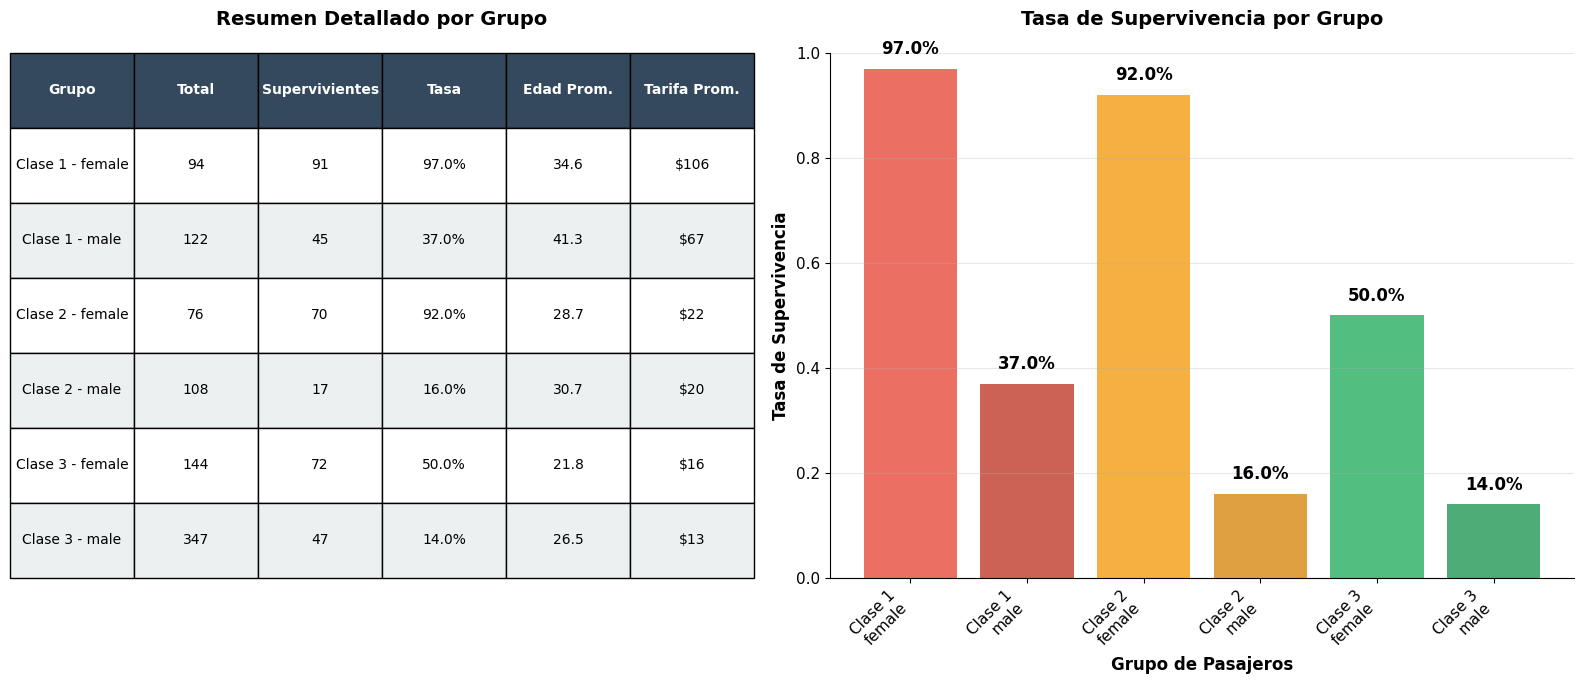

In [16]:
#| label: fig-readable-design
#| fig-cap: Diseño optimizado para legibilidad con tipografía clara

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: Tabla visual con datos claros
survival_summary = df.groupby(['Pclass', 'Sex']).agg({
    'Survived': ['count', 'sum', 'mean'],
    'Age': 'mean',
    'Fare': 'mean'
}).round(2)

# Simplificar columnas
survival_summary.columns = ['Total', 'Supervivientes', 'Tasa_Supervivencia', 'Edad_Promedio', 'Tarifa_Promedio']
survival_summary = survival_summary.reset_index()

# Crear tabla visual
table_data = []
for _, row in survival_summary.iterrows():
    table_data.append([
        f"Clase {row['Pclass']} - {row['Sex']}",
        f"{row['Total']:.0f}",
        f"{row['Supervivientes']:.0f}",
        f"{row['Tasa_Supervivencia']:.1%}",
        f"{row['Edad_Promedio']:.1f}",
        f"${row['Tarifa_Promedio']:.0f}"
    ])

table = ax1.table(cellText=table_data,
                  colLabels=['Grupo', 'Total', 'Supervivientes', 'Tasa', 'Edad Prom.', 'Tarifa Prom.'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Colorear header
for i in range(6):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Colorear filas alternadas
for i in range(1, len(table_data) + 1):
    for j in range(6):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')

ax1.axis('off')
ax1.set_title('Resumen Detallado por Grupo', fontweight='bold', pad=20)

# Gráfico 2: Barras con etiquetas claras
categories = [f"Clase {row['Pclass']}\n{row['Sex']}" for _, row in survival_summary.iterrows()]
survival_rates = survival_summary['Tasa_Supervivencia'].values

colors = ['#e74c3c', '#c0392b', '#f39c12', '#d68910', '#27ae60', '#229954']
bars = ax2.bar(range(len(categories)), survival_rates, color=colors, alpha=0.8)

ax2.set_xlabel('Grupo de Pasajeros', fontweight='bold')
ax2.set_ylabel('Tasa de Supervivencia', fontweight='bold')
ax2.set_title('Tasa de Supervivencia por Grupo', fontweight='bold', pad=20)
ax2.set_xticks(range(len(categories)))
ax2.set_xticklabels(categories, rotation=45, ha='right')
ax2.set_ylim(0, 1)

# Agregar etiquetas de valor en las barras
for bar, rate in zip(bars, survival_rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')

ax2.grid(True, axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

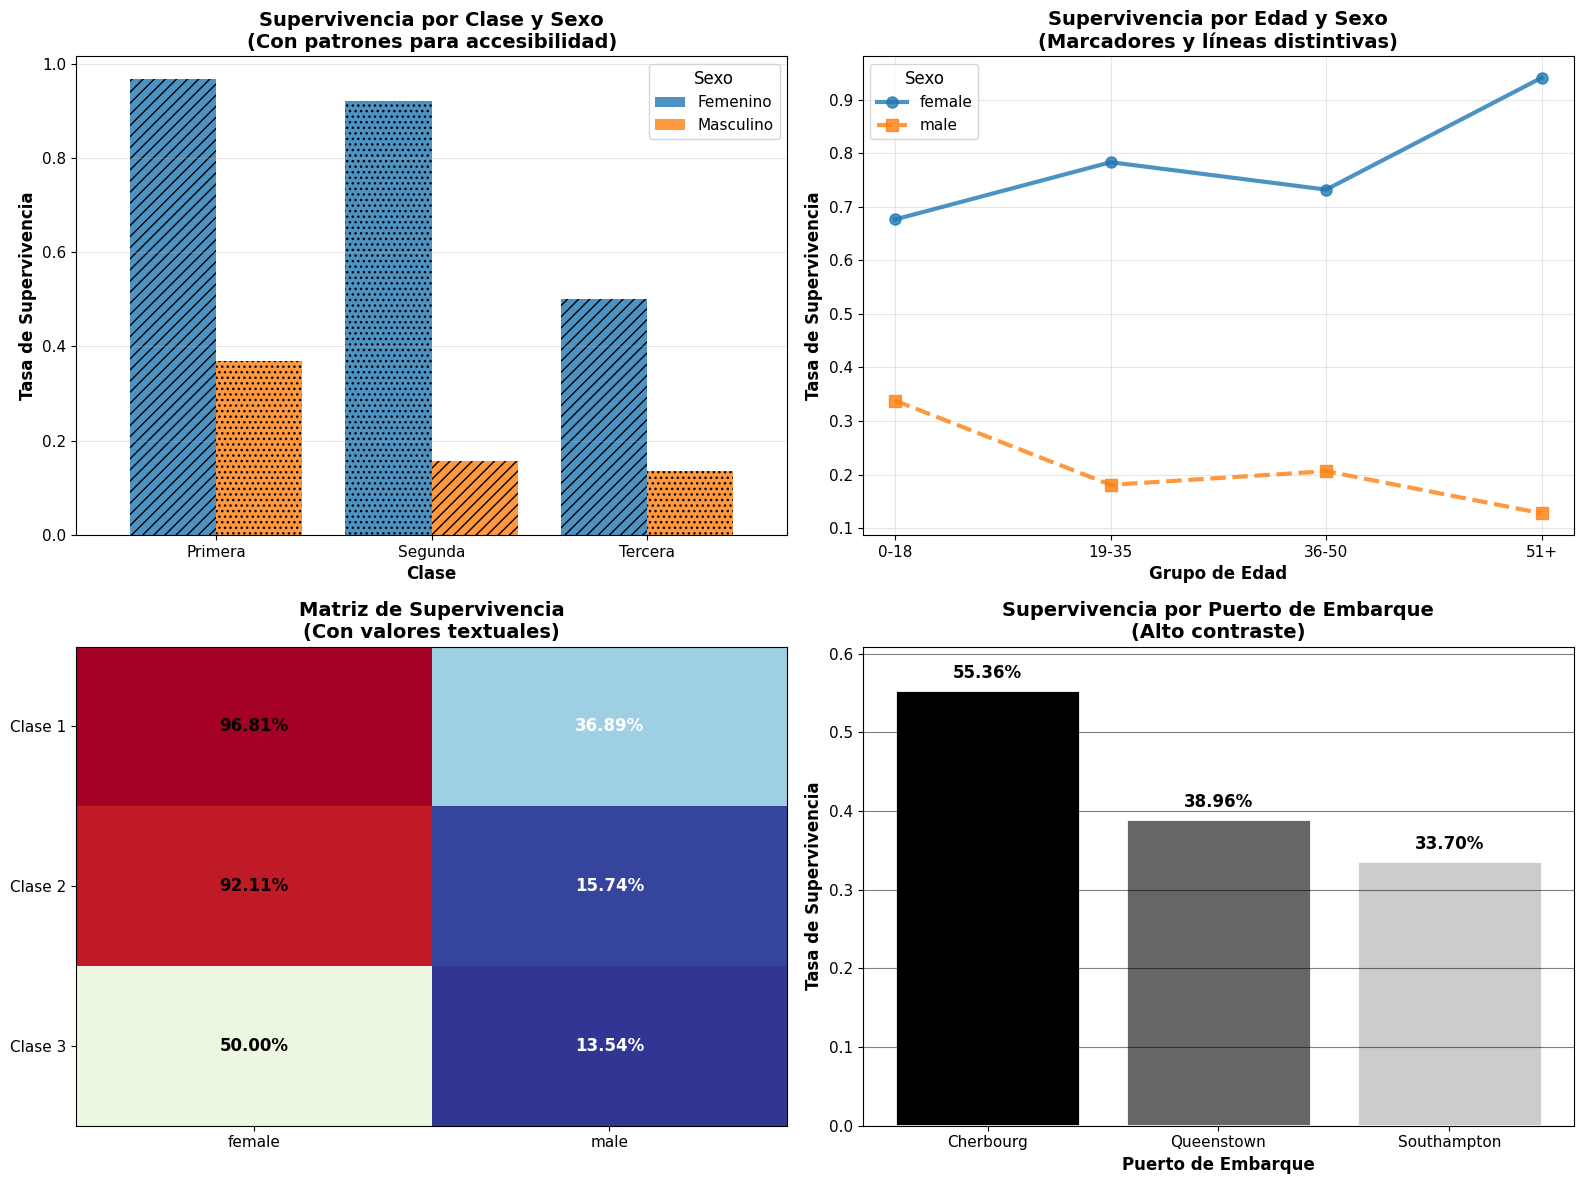

In [17]:
#| label: fig-accessible-design
#| fig-cap: Diseño accesible con patrones y contrastes apropiados

# Paleta de colores accesible para daltónicos
accessible_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gráfico con patrones además de colores
survival_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

bars1 = survival_by_class_sex.plot(kind='bar', ax=ax1, color=accessible_colors[:2], 
                                   alpha=0.8, width=0.8)
ax1.set_xlabel('Clase', fontweight='bold')
ax1.set_ylabel('Tasa de Supervivencia', fontweight='bold')
ax1.set_title('Supervivencia por Clase y Sexo\n(Con patrones para accesibilidad)', fontweight='bold')
ax1.legend(['Femenino', 'Masculino'], title='Sexo')
ax1.set_xticklabels(['Primera', 'Segunda', 'Tercera'], rotation=0)
ax1.grid(True, axis='y', alpha=0.3)

# Agregar patrones a las barras
bars = ax1.patches
patterns = ['///', '...']  # Patrones diferentes para cada sexo
for i, bar in enumerate(bars):
    pattern_idx = i % 2
    bar.set_hatch(patterns[pattern_idx])

# 2. Gráfico de líneas con marcadores distintivos
age_groups = pd.cut(df['Age'], bins=[0, 18, 35, 50, 100], labels=['0-18', '19-35', '36-50', '51+'])
survival_by_age_sex = df.groupby([age_groups, 'Sex'])['Survived'].mean().unstack()

markers = ['o', 's']  # Círculos y cuadrados
linestyles = ['-', '--']  # Línea sólida y punteada

for i, sex in enumerate(survival_by_age_sex.columns):
    ax2.plot(range(len(survival_by_age_sex.index)), survival_by_age_sex[sex], 
             marker=markers[i], linestyle=linestyles[i], linewidth=3, markersize=8,
             color=accessible_colors[i], label=sex, alpha=0.8)

ax2.set_xlabel('Grupo de Edad', fontweight='bold')
ax2.set_ylabel('Tasa de Supervivencia', fontweight='bold')
ax2.set_title('Supervivencia por Edad y Sexo\n(Marcadores y líneas distintivas)', fontweight='bold')
ax2.set_xticks(range(len(survival_by_age_sex.index)))
ax2.set_xticklabels(survival_by_age_sex.index)
ax2.legend(title='Sexo')
ax2.grid(True, alpha=0.3)

# 3. Heatmap con texto para mayor accesibilidad
pivot_data = df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')
im = ax3.imshow(pivot_data.values, cmap='RdYlBu_r', aspect='auto')

# Agregar texto en cada celda
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        value = pivot_data.iloc[i, j]
        text_color = 'white' if value < 0.5 else 'black'
        ax3.text(j, i, f'{value:.2%}', ha='center', va='center', 
                color=text_color, fontweight='bold', fontsize=12)

ax3.set_xticks(range(len(pivot_data.columns)))
ax3.set_yticks(range(len(pivot_data.index)))
ax3.set_xticklabels(pivot_data.columns)
ax3.set_yticklabels([f'Clase {i}' for i in pivot_data.index])
ax3.set_title('Matriz de Supervivencia\n(Con valores textuales)', fontweight='bold')

# 4. Gráfico con alto contraste
embarked_survival = df.groupby('Embarked')['Survived'].mean().sort_values(ascending=False)
bars4 = ax4.bar(range(len(embarked_survival)), embarked_survival.values, 
                color=['#000000', '#666666', '#CCCCCC'], edgecolor='white', linewidth=2)

ax4.set_xlabel('Puerto de Embarque', fontweight='bold')
ax4.set_ylabel('Tasa de Supervivencia', fontweight='bold')
ax4.set_title('Supervivencia por Puerto de Embarque\n(Alto contraste)', fontweight='bold')
ax4.set_xticks(range(len(embarked_survival)))
ax4.set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'])

# Agregar valores con buen contraste
for bar, value in zip(bars4, embarked_survival.values):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{value:.2%}', ha='center', va='bottom', 
             fontweight='bold', fontsize=12, color='black')

ax4.grid(True, axis='y', alpha=0.5, color='black')
ax4.set_ylim(0, max(embarked_survival.values) * 1.1)

plt.tight_layout()
plt.show()

In [18]:
#| label: statistical-analysis


from scipy import stats

# Pruebas estadísticas
display(Markdown("### Análisis Estadístico:"))

# Test de normalidad para la edad
shapiro_stat, shapiro_p = stats.shapiro(df['Age'].dropna())
display(Markdown(f"""
**Prueba de Normalidad (Shapiro-Wilk) para Edad:**
- Estadístico: {shapiro_stat:.4f}
- p-valor: {shapiro_p:.4f}
- Interpretación: {'Los datos siguen una distribución normal' if shapiro_p > 0.05 else 'Los datos NO siguen una distribución normal'}
"""))

# Test Chi-cuadrado para independencia entre clase y supervivencia
contingency_table = pd.crosstab(df['Pclass'], df['Survived'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency_table)

display(Markdown(f"""
**Prueba Chi-cuadrado (Clase vs Supervivencia):**
- Estadístico Chi-cuadrado: {chi2:.4f}
- p-valor: {p_chi2:.4f}
- Grados de libertad: {dof}
- Interpretación: {'Existe asociación significativa' if p_chi2 < 0.05 else 'No existe asociación significativa'}
"""))

# Correlaciones
correlations = df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']].corr()['Survived'].sort_values(ascending=False)
display(Markdown("**Correlaciones con Supervivencia:**"))
for var, corr in correlations.items():
    if var != 'Survived':
        display(Markdown(f"- {var}: {corr:.4f}"))

### Análisis Estadístico:


**Prueba de Normalidad (Shapiro-Wilk) para Edad:**
- Estadístico: 0.9815
- p-valor: 0.0000
- Interpretación: Los datos NO siguen una distribución normal



**Prueba Chi-cuadrado (Clase vs Supervivencia):**
- Estadístico Chi-cuadrado: 102.8890
- p-valor: 0.0000
- Grados de libertad: 2
- Interpretación: Existe asociación significativa


**Correlaciones con Supervivencia:**

- Fare: 0.2573

- Parch: 0.0816

- SibSp: -0.0353

- Age: -0.0772

In [19]:
#| label: key-findings
#| echo: false

# Calcular insights clave
insights = {
    'supervivencia_general': df['Survived'].mean(),
    'supervivencia_mujeres': df[df['Sex'] == 'female']['Survived'].mean(),
    'supervivencia_hombres': df[df['Sex'] == 'male']['Survived'].mean(),
    'supervivencia_primera_clase': df[df['Pclass'] == 1]['Survived'].mean(),
    'supervivencia_tercera_clase': df[df['Pclass'] == 3]['Survived'].mean(),
    'edad_promedio_supervivientes': df[df['Survived'] == 1]['Age'].mean(),
    'edad_promedio_no_supervivientes': df[df['Survived'] == 0]['Age'].mean()
}

display(Markdown(f"""
1. **Sexo**: Las mujeres tuvieron una tasa de supervivencia del {insights['supervivencia_mujeres']:.1%}, 
   comparado con {insights['supervivencia_hombres']:.1%} de los hombres.

2. **Clase Social**: Los pasajeros de primera clase tuvieron una supervivencia del {insights['supervivencia_primera_clase']:.1%}, 
   mientras que los de tercera clase solo {insights['supervivencia_tercera_clase']:.1%}.

3. **Edad**: Los supervivientes tenían una edad promedio de {insights['edad_promedio_supervivientes']:.1f} años, 
   comparado con {insights['edad_promedio_no_supervivientes']:.1f} años de quienes no sobrevivieron.

4. **Protocolo "Mujeres y Niños Primero"**: Se confirma estadísticamente la aplicación de este protocolo.
"""))


1. **Sexo**: Las mujeres tuvieron una tasa de supervivencia del 74.2%, 
   comparado con 18.9% de los hombres.

2. **Clase Social**: Los pasajeros de primera clase tuvieron una supervivencia del 63.0%, 
   mientras que los de tercera clase solo 24.2%.

3. **Edad**: Los supervivientes tenían una edad promedio de 28.3 años, 
   comparado con 30.6 años de quienes no sobrevivieron.

4. **Protocolo "Mujeres y Niños Primero"**: Se confirma estadísticamente la aplicación de este protocolo.
